<a href="https://colab.research.google.com/github/wairiukoirwine/WEATHERPREDICIONMODEL/blob/main/weatherpredictionmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
from google.colab import files
uploaded = files.upload()

Saving seattle-weather.csv to seattle-weather (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

print(" All libraries loaded successfully!")

In [32]:
import zipfile

# Unzip the uploaded archive
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv('seattle-weather.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1461, 6)

First 5 rows:


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [33]:
print("Column names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget column distribution:")
print(df['weather'].value_counts())

Column names: ['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']

Data types:
 date              object
precipitation    float64
temp_max         float64
temp_min         float64
wind             float64
weather           object
dtype: object

Missing values:
 date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

Target column distribution:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


In [34]:
# The 'weather' column has: rain, sun, fog, drizzle, snow
# We simplify it to binary: 1 = Rain, 0 = No Rain

df['rain'] = df['weather'].apply(lambda x: 1 if x == 'rain' else 0)

print("Binary target distribution:")
print(df['rain'].value_counts())
print(f"\nRain days    : {df['rain'].sum()} ({df['rain'].mean()*100:.1f}%)")
print(f"Non-rain days: {(df['rain']==0).sum()} ({(df['rain']==0).mean()*100:.1f}%)")

Binary target distribution:
rain
0    820
1    641
Name: count, dtype: int64

Rain days    : 641 (43.9%)
Non-rain days: 820 (56.1%)


In [35]:
# Select input features (drop date and original weather column)
features = ['precipitation', 'temp_max', 'temp_min', 'wind']

X = df[features]
y = df['rain']

print("Features (X):")
print(X.describe().round(2))
print(f"\nTarget (y): {y.shape[0]} rows")

Features (X):
       precipitation  temp_max  temp_min     wind
count        1461.00   1461.00   1461.00  1461.00
mean            3.03     16.44      8.23     3.24
std             6.68      7.35      5.02     1.44
min             0.00     -1.60     -7.10     0.40
25%             0.00     10.60      4.40     2.20
50%             0.00     15.60      8.30     3.00
75%             2.80     22.20     12.20     4.00
max            55.90     35.60     18.30     9.50

Target (y): 1461 rows


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions: Rain vs No Rain', fontsize=15, fontweight='bold')

colors = {0: '#065A82', 1: '#02C39A'}
labels = {0: 'No Rain', 1: 'Rain'}
feat_labels = ['Precipitation (mm)', 'Max Temp (°C)', 'Min Temp (°C)', 'Wind Speed (km/h)']

for ax, feat, label in zip(axes.flat, features, feat_labels):
    for val in [0, 1]:
        subset = df[df['rain'] == val][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=colors[val], label=labels[val], edgecolor='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.savefig('fig1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved!")

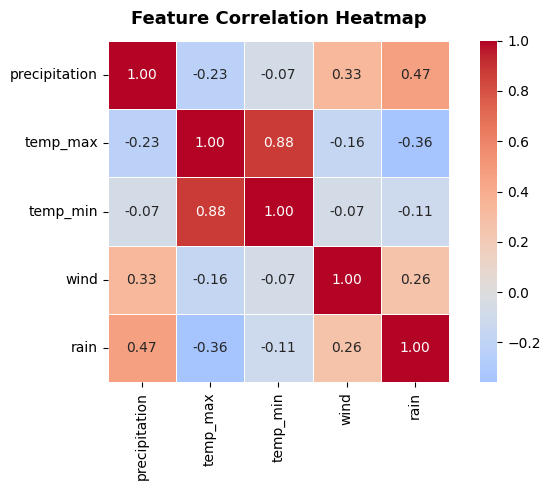

✅ Heatmap saved!


In [45]:
plt.figure(figsize=(7, 5))
corr = df[features + ['rain']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print("✅ Data split and scaled!")

Training samples : 1168
Testing  samples : 293
✅ Data split and scaled!


In [44]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("✅ Model trained!")
print("\nModel coefficients (feature weights):")
for feat, coef in zip(features, model.coef_[0]):
    direction = "↑ increases rain chance" if coef > 0 else "↓ decreases rain chance"
    print(f"  {feat:15s}: {coef:+.4f}  {direction}")

✅ Model trained!

Model coefficients (feature weights):
  precipitation  : +3.1354  ↑ increases rain chance
  temp_max       : -2.3332  ↓ decreases rain chance
  temp_min       : +1.9109  ↑ increases rain chance
  wind           : +0.1036  ↑ increases rain chance


In [41]:
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"{'='*45}")
print(f"  ACCURACY: {acc*100:.2f}%")
print(f"{'='*45}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))

  ACCURACY: 85.32%

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.83      0.92      0.88       164
        Rain       0.88      0.77      0.82       129

    accuracy                           0.85       293
   macro avg       0.86      0.84      0.85       293
weighted avg       0.86      0.85      0.85       293



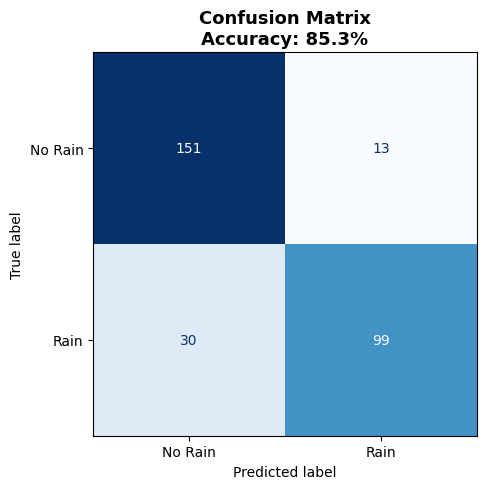

✅ Confusion matrix saved!


In [40]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix\nAccuracy: {acc*100:.1f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

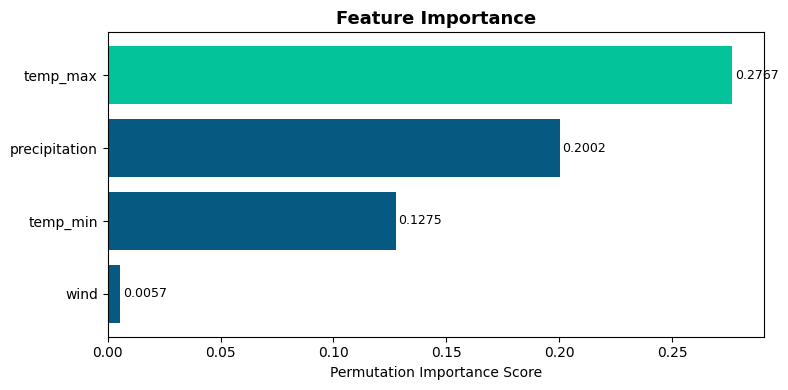

✅ Feature importance chart saved!


In [37]:
pi = permutation_importance(model, X_test_scaled, y_test, n_repeats=30, random_state=42)
importance_df = pd.DataFrame({
    'feature': features,
    'importance': pi.importances_mean
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['#02C39A' if i == len(importance_df)-1 else '#065A82'
          for i in range(len(importance_df))]
bars = plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('Permutation Importance Score')
plt.title('Feature Importance', fontsize=13, fontweight='bold')
for bar, val in zip(bars, importance_df['importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved!")

In [39]:
print("=" * 50)
print("       PROJECT SUMMARY — SEATTLE WEATHER")
print("=" * 50)
print(f"  Dataset        : seattle-weather.csv")
print(f"  Total records  : {len(df)}")
print(f"  Features used  : {features}")
print(f"  Model          : Logistic Regression")
print(f"  Accuracy       : {acc*100:.2f}%")
print(f"  Test samples   : {len(y_test)}")
print(f"  Correct preds  : {int(acc * len(y_test))}/{len(y_test)}")
print("=" * 50)
print("✅ Project complete! All charts saved.")

       PROJECT SUMMARY — SEATTLE WEATHER
  Dataset        : seattle-weather.csv
  Total records  : 1461
  Features used  : ['precipitation', 'temp_max', 'temp_min', 'wind']
  Model          : Logistic Regression
  Accuracy       : 85.32%
  Test samples   : 293
  Correct preds  : 250/293
✅ Project complete! All charts saved.
